In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
dataset_path = r"D:\Data Science and Analytics\miniproject\cattle"

print(os.path.exists(dataset_path))

True


In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],
    validation_split=0.2
)

In [4]:
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [5]:
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

Found 16566 images belonging to 4 classes.


In [6]:
validation_generator = validation_datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 4139 images belonging to 4 classes.


In [7]:
print(train_generator.class_indices)

{'FMD': 0, 'IBK': 1, 'LSD': 2, 'Normal': 3}


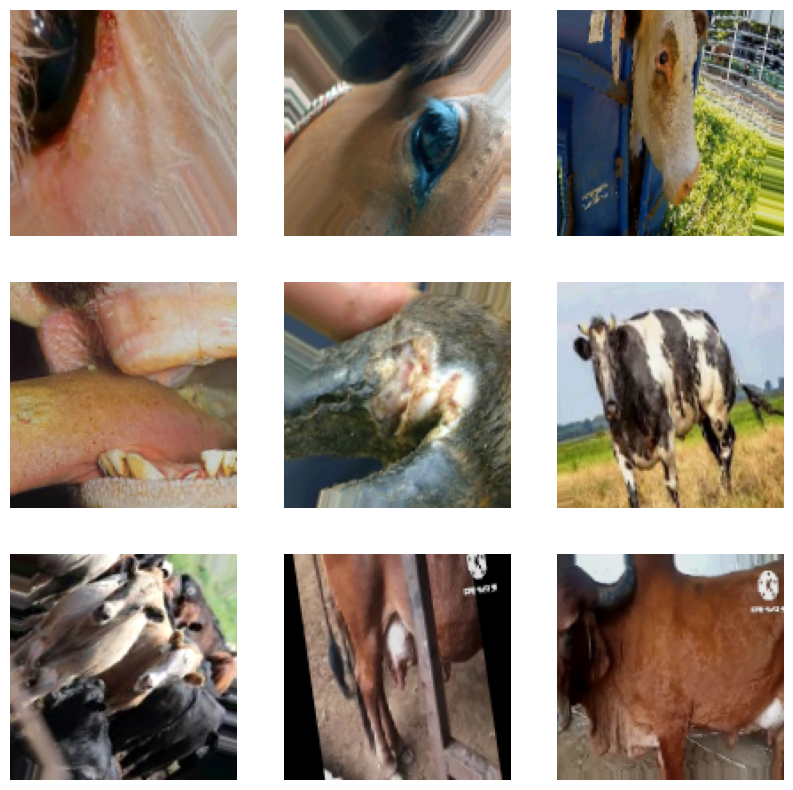

In [8]:
images, labels = next(train_generator)

plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()

In [9]:
model = Sequential([

    Input(shape=(128, 128, 3)),

    # Block 1
    Conv2D(32, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Block 2
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Block 3
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Feature Reduction
    GlobalAveragePooling2D(),

    # Classification
    Dense(128, activation='relu'),
    Dropout(0.5),

    # 4 Classes
    Dense(4, activation='softmax')
])

In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 126, 126, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 61, 61, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 28, 28, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 111,172 (434.27 KB)

 Trainable params: 110,724 (432.52 KB)

 Non-trainable params: 448 (1.75 KB)

In [12]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [13]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
518/518 ━━━━━━━━━━━━━━━━━━━━ 1043s 2s/step - accuracy: 0.6535 - loss: 0.8772 - val_accuracy: 0.6021 - val_loss: 1.0969
Epoch 2/10
518/518 ━━━━━━━━━━━━━━━━━━━━ 472s 908ms/step - accuracy: 0.7485 - loss: 0.6568 - val_accuracy: 0.5006 - val_loss: 1.8201
Epoch 3/10
518/518 ━━━━━━━━━━━━━━━━━━━━ 453s 875ms/step - accuracy: 0.8062 - loss: 0.5246 - val_accuracy: 0.7415 - val_loss: 0.8497
Epoch 4/10
518/518 ━━━━━━━━━━━━━━━━━━━━ 461s 890ms/step - accuracy: 0.8508 - loss: 0.4106 - val_accuracy: 0.4557 - val_loss: 4.5843
Epoch 5/10
518/518 ━━━━━━━━━━━━━━━━━━━━ 459s 885ms/step - accuracy: 0.8863 - loss: 0.3312 - val_accuracy: 0.7511 - val_loss: 0.7768
Epoch 6/10
518/518 ━━━━━━━━━━━━━━━━━━━━ 462s 892ms/step - accuracy: 0.9036 - loss: 0.2827 - val_accuracy: 0.8541 - val_loss: 0.4787
Epoch 7/10
518/518 ━━━━━━━━━━━━━━━━━━━━ 461s 891ms/step - accuracy: 0.9136 - loss: 0.2587 - val_accuracy: 0.5289 - val_loss: 2.7507
Epoch 8/10
518/518 ━━━━━━━━━━━━━━━━━━━━ 464s 895ms/step - accuracy: 0.9213 - l

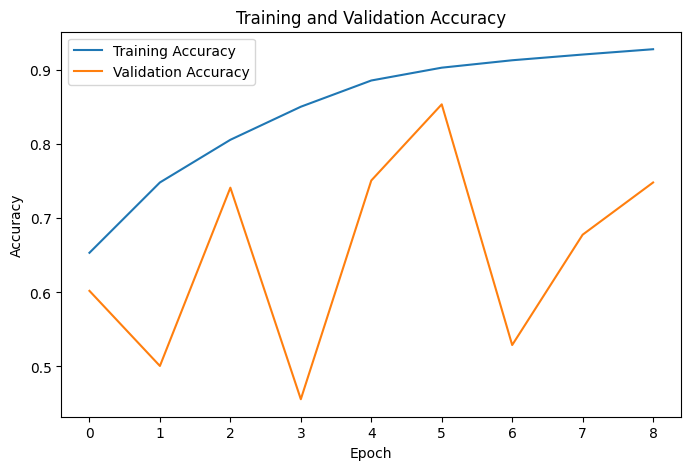

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

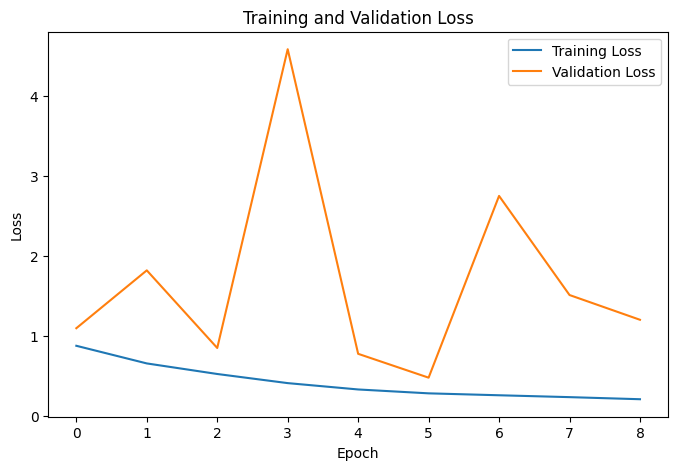

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [16]:
results = model.evaluate(
    validation_generator,
    verbose=1
)

print("Validation Loss:", results[0])
print("Validation Accuracy:", results[1])

130/130 ━━━━━━━━━━━━━━━━━━━━ 39s 301ms/step - accuracy: 0.8541 - loss: 0.4787
Validation Loss: 0.47871702909469604
Validation Accuracy: 0.8540710210800171


130/130 ━━━━━━━━━━━━━━━━━━━━ 36s 270ms/step


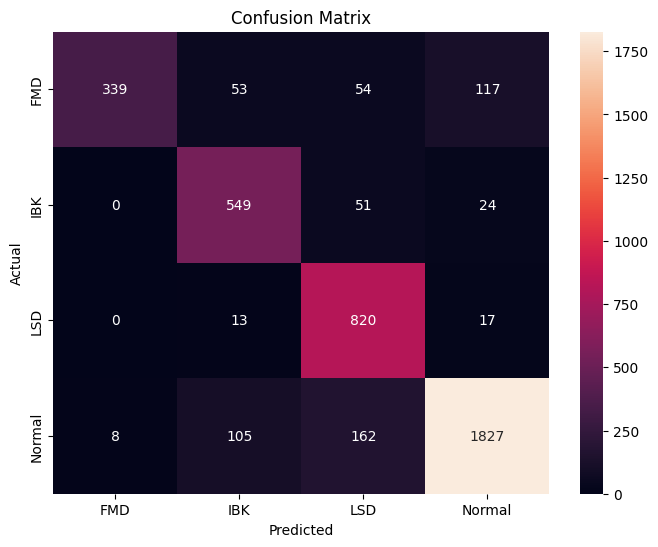

In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Reset validation generator
validation_generator.reset()

# Predictions
predictions = model.predict(validation_generator)

# Convert probabilities to class numbers
y_pred = np.argmax(predictions, axis=1)

# Actual class numbers
y_true = validation_generator.classes

# Class names
class_names = list(validation_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [18]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

         FMD       0.98      0.60      0.75       563
         IBK       0.76      0.88      0.82       624
         LSD       0.75      0.96      0.85       850
      Normal       0.92      0.87      0.89      2102

    accuracy                           0.85      4139
   macro avg       0.85      0.83      0.83      4139
weighted avg       0.87      0.85      0.85      4139



In [19]:
model.save("livestock_skin_disease_cnn.keras")

In [20]:
import os

print(os.path.exists("livestock_skin_disease_cnn.keras"))

True


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step
Predicted Disease: LSD
Confidence: 94.49 %


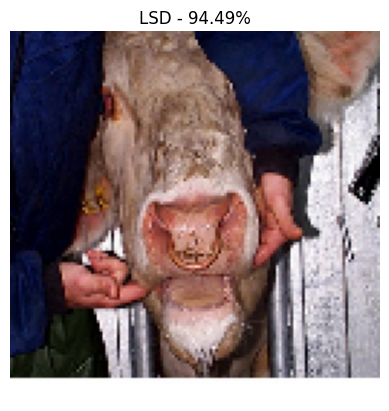

In [25]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img_path = r"D:\Data Science and Analytics\miniproject\images\test.jpg"

img = image.load_img(img_path, target_size=(128, 128))

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

class_names = ['FMD', 'IBK', 'LSD', 'Normal']

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

print("Predicted Disease:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

plt.imshow(img)
plt.axis("off")
plt.title(f"{predicted_class} - {confidence:.2f}%")
plt.show()

In [1]:
import os

print(os.path.exists("livestock_skin_disease_cnn.keras"))

True


In [ ]:
from tensorflow.keras.models import load_model

model = load_model("livestock_skin_disease_cnn.keras")

print("Model loaded successfully!")

Predicted Disease: LSD
Confidence: 99.49 %


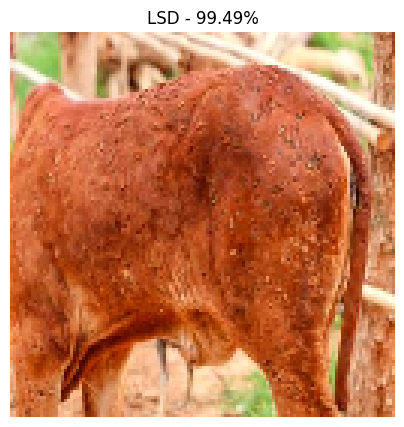

In [3]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img_path = r"D:\Data Science and Analytics\miniproject\images\test2.jpg"

# Load image
img = image.load_img(img_path, target_size=(128, 128))

# Convert image to array
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Prediction
prediction = model.predict(img_array, verbose=0)

# Class names
class_names = ['FMD', 'IBK', 'LSD', 'Normal']

# Get prediction
predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

print("Predicted Disease:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

# Display image
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.title(f"{predicted_class} - {confidence:.2f}%")
plt.show()

Predicted Disease: IBK
Confidence: 99.99 %


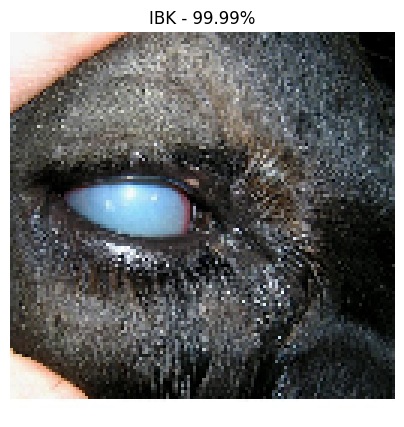

In [4]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img_path = r"D:\Data Science and Analytics\miniproject\images\test3.jpg"

# Load image
img = image.load_img(img_path, target_size=(128, 128))

# Convert image to array
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Prediction
prediction = model.predict(img_array, verbose=0)

# Class names
class_names = ['FMD', 'IBK', 'LSD', 'Normal']

# Get prediction
predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

print("Predicted Disease:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

# Display image
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.title(f"{predicted_class} - {confidence:.2f}%")
plt.show()

Predicted Disease: Normal
Confidence: 95.47 %


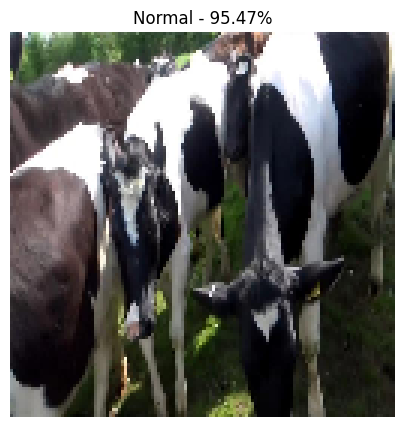

In [6]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img_path = r"D:\Data Science and Analytics\miniproject\images\test4.jpg"

# Load image
img = image.load_img(img_path, target_size=(128, 128))

# Convert image to array
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Prediction
prediction = model.predict(img_array, verbose=0)

# Class names
class_names = ['FMD', 'IBK', 'LSD', 'Normal']

# Get prediction
predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

print("Predicted Disease:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

# Display image
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.title(f"{predicted_class} - {confidence:.2f}%")
plt.show()

In [2]:
from tensorflow.keras.models import load_model

model = load_model("livestock_skin_disease_cnn.keras")

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img_path = r"D:\Data Science and Analytics\miniproject\images\test4.jpg"

# Load image
img = image.load_img(img_path, target_size=(128, 128))

# Convert image to array
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Prediction
prediction = model.predict(img_array, verbose=0)

# Class names
class_names = ['FMD', 'IBK', 'LSD', 'Normal']

# Get prediction
predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

print("Predicted Disease:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

# Display image
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.title(f"{predicted_class} - {confidence:.2f}%")
plt.show()